<h4> Zadanie1 (1pkt): Rozważamy dane dotyczące ekspresji genów z odpowiedzi ludzkich astrocytów U251 na zakażenie wirusem grypy H5N1. Badanie to dostarcza informacji na temat odpowiedzi immunologicznej astrocytów na infekcję wirusową.
    
- Narysuj zależność $LIF$ vs $SHPRH$ oraz $LIF$ vs $IL11$. Skomentuj otrzymane wykresy (także biologicznie, co to może oznaczać?).  
- Zaproponuj adekwatną zależność $LIF \sim f_1(SHRPH)+f_2(IL11)+$, gdzie $f_1$ i $f_2$ to pewne transformacje (np. wielomianowe, maksymalnie 4-5 wag). Uzasadnij swój wybór. Nie wydzielaj zbiorów: treningowego/testowego (mało danych). 
- Wyznacz MSE dla modelu oraz narysuj zależność $LIF$ vs $LIF^p$.

In [69]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.pipeline import make_pipeline
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [5]:
df = pd.read_csv('genes_cig.txt', sep = ",")
df.head()

,LIF,IL11,SHPRH
0,9.19007,7.25721,6.79607
1,9.26944,7.65776,6.71755
2,9.35100,7.62542,6.80711
3,8.64706,7.37893,6.83646
4,8.92314,7.60337,7.07751


In [41]:
target = df['LIF']
df['IL11_kwadrat'] = df['IL11']**2
d2 = df[['IL11', 'SHPRH','IL11_kwadrat']]

X = d2.values.tolist()
y = target.tolist()

def update_weights(w1, w2, w3, w0, X, t, eta):
    N = len(t)
    
    #pochodne
    dw1 = 0
    dw2 = 0
    dw3 = 0
    dw0 = 0

    for i in range(N):
        x1_i = X[i][0]
        x2_i = X[i][1]
        x3_i = X[i][2]
        t_i = t[i] #Y 

        predykcja = w1 * x1_i + w2 * x2_i + w3 * x3_i + w0 # Y przewidywany
        error = predykcja - t_i 

        #gradienty
        dw1 += error * x1_i
        dw2 += error * x2_i
        dw3 += error * x3_i
        dw0 += error 
        
    #Aktualizacje pochodnych  
    dw1 = (2/N) * dw1
    dw2 = (2/N) * dw2
    dw3 = (2/N) * dw3
    dw0 = (2/N) * dw0

    new_w1 = w1 - eta * dw1
    new_w2 = w2 - eta * dw2
    new_w3 = w3 - eta * dw3
    new_w0 = w0 - eta * dw0

    return new_w1, new_w2, new_w3, new_w0


In [40]:
#Pętla uczaca 
#Zaczynam np. od samych 0
obecne_w1, obecne_w2, obecne_w3, obecne_w0 = 0.0, 0.0, 0.0, 0.0

#Ilość iteracji 
iteracje = 5000
eta = 0.0001
#Dla eta = 0.001 liczby zaczęły dażyć do nieskończonosci i było same nan

#Pętla
for i in range(iteracje):
    obecne_w1, obecne_w2, obecne_w3, obecne_w0 = update_weights(obecne_w1, obecne_w2, obecne_w3, obecne_w0, X, y, eta)
    

-0.06421308297365527 -0.04495763723438579 0.011417701617942396 -0.014012354302525133


In [35]:
#Końcowe wyniki
print("Wyuczone wagi:")
print(f"w1 = {obecne_w1}")
print(f"w2 = {obecne_w2}")
print(f"w3 = {obecne_w3}")
print(f"w0 = {obecne_w0}")

Wyuczone wagi:
w1 = 0.32334458567911983
w2 = 0.5395435591992493
w3 = 0.054726091226054346
w0 = 0.07415133586133255


<h4> Zależność która wykorzystałam przyjmuje wzór $LIF$ = $w0$ + $w1$ * $SHPRH$ + $w2$ * $IL11$ + $w3$ * $IL11^2$
    Aby zwiększyć ilość wag, zastosowałam wielomian drugiego stopnia, co chroni model przed przeuczeniem.

In [43]:
#MSE
N = len(y)
mse = 0
target_przewidywanie = []

for i in range(N):
    x1_i = X[i][0]
    x2_i = X[i][1] 
    x3_i = X[i][2] 
    t_i = y[i]

    predykcja = obecne_w1 * x1_i + obecne_w2 * x2_i + obecne_w3 * x3_i + obecne_w0
    target_przewidywanie.append(predykcja)
    
    blad = predykcja - t_i
    mse += blad ** 2

mse_koncowe = mse / N

print(f"MSE modelu wynosi: {mse_koncowe:.4f}")

MSE modelu wynosi: 0.1054


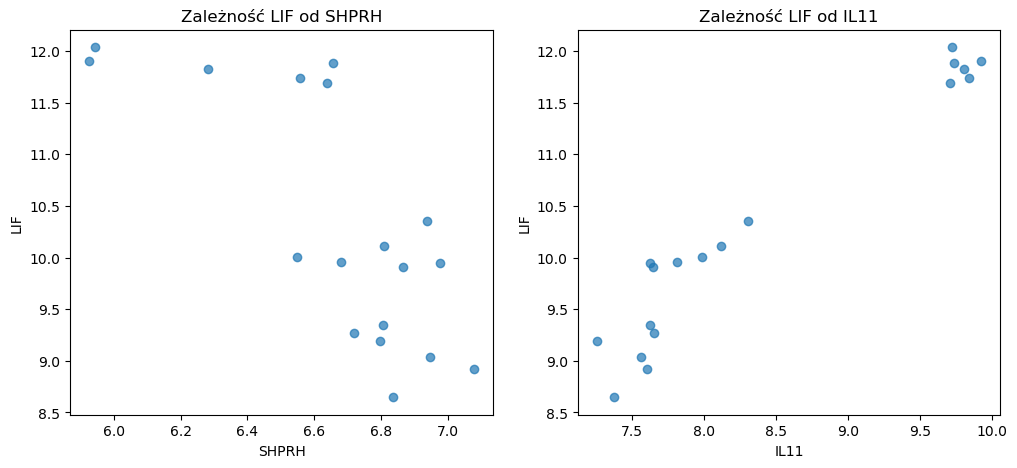

In [29]:
#Wykresy poczatkowe
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(df['SHPRH'], df['LIF'], alpha=0.7)
axes[0].set_title('Zależność LIF od SHPRH')
axes[0].set_xlabel('SHPRH')
axes[0].set_ylabel('LIF')

axes[1].scatter(df['IL11'], df['LIF'], alpha=0.7)
axes[1].set_title('Zależność LIF od IL11')
axes[1].set_xlabel('IL11')
axes[1].set_ylabel('LIF')

plt.show()

<h4> Możemy zauważyć, że zależność LIF od IL11 układa się jak linia rosnaca idaca od lewego dolnego rogu, natomiast LIF od SHPRH tez wykazuje zależność (tak jakby) liniowa, ale idcaca od lewego górnego rogu. LIF vs IL11 może oznaczać, że wzrost ekspresji jednego wpływa na wzrostu drugiego, natomiast LIF vs SHPRH wskazuje, że gdy ekspresja jednego rośnie, ekspresja drugiego maleje.

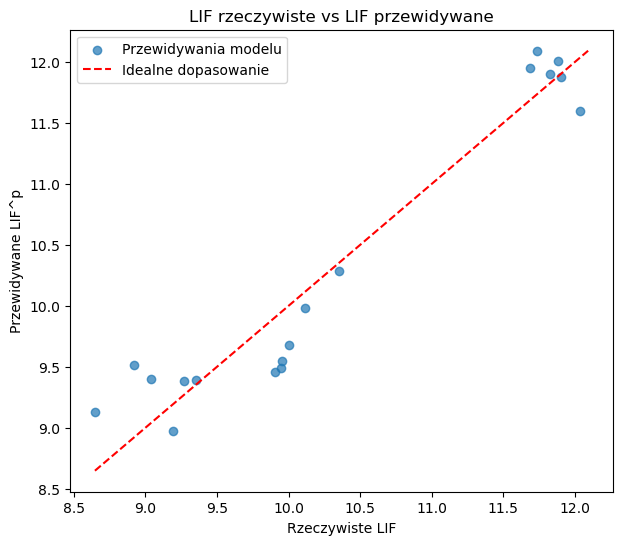

In [45]:
#Wykres LIF vs LIF^p
plt.figure(figsize=(7, 6))
plt.scatter(y, target_przewidywanie, alpha=0.7, label='Przewidywania modelu')

min_val = min(min(y), min(target_przewidywanie))
max_val = max(max(y), max(target_przewidywanie))
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Idealne dopasowanie')

plt.title('LIF rzeczywiste vs LIF przewidywane')
plt.xlabel('Rzeczywiste LIF')
plt.ylabel('Przewidywane LIF^p')
plt.legend()
plt.show()

<h4> Zadanie2 (3pkt): Rozważ dane dotyczace lokalizacji komórkowej wybranych białek (peptydów).
    
- Pozostaw kategorie: MT (mitochondrialne), SP (sygnałowe), CH (chloroplastów), TH (lumen tylakoidów), czyli odrzuć rekordy Other
- Czy rozważany zbiór danych jest zbalansowany?
- Wybierz cechy do reprezentacji rozważanych sekwencji
- Narysuj histogramy/wykresy pudełkowe rozważanych cech względem kategorii
- Podziel dane na zbiór treningowy i testowy (ewentualnie wydziel jeszcze zbiór walidacyjny)
- Dokonaj standaryzacji danych
- Zbuduj model regresji logistycznej, które zmienne najbardziej istotne?

!!!Zbuduj wiele modeli, pokazując proces tworzenia bardziej użytecznych modeli!!! Co warto zrobić?
- class_weight='balanced' jako argument LR
- SMOTE (z imblearn) - dogenerować kolejne dane, zrób to tylko na zbiorze treningowym! po podziale! czemu?
- wybór innych cech
- rozważ nieliniowe transformacje
- rozważ regularyzację (zwłaszcza przy dużej liczbie cech)
- ... im więcej ciekawych pomysłów tym lepiej

In [46]:
from Bio import SeqIO

plik_fasta = "targetp.fasta"
plik_etykiety = "swissprot_annotated_proteins.tab"

# Tworzymy pusty słownik
sekwencje = []

ids = []
sqs = []

for rekord in SeqIO.parse(plik_fasta, "fasta"):
    ids.append(str(rekord.id))
    sqs.append(str(rekord.seq))
    
df_seq = pd.DataFrame({'ID': ids, 'Sequence': sqs})
df_etykiety = pd.read_csv(plik_etykiety, sep='\t', header=None, names=['ID', 'Target', 'Dodatkowa_wartosc'])
df = pd.merge(df_seq, df_etykiety, on='ID')

#Filtracja danych 'Other'
kategorie = ['MT', 'SP', 'CH', 'TH']
df_filtered = df[df['Target'].isin(kategorie)].copy()

#Czy zbalansowane
print("Zbiór klas:")
rozkład = df_filtered['Target'].value_counts()
print(rozkład)
print('Zbiór nie jest zbalansowany')


Zbiór klas:
Target
SP    2697
MT     499
CH     227
TH      45
Name: count, dtype: int64
Zbiór nie jest zbalansowany


In [59]:
#Wybór cech
from Bio.SeqUtils.ProtParam import ProteinAnalysis
#Przez obecność aminokwasów niejednoznacznych w sekwencjach, usunełam te aminokwasy aby program działał , inaczej Error :(

def extract_features(sequence):
    dozwolone = set('ACDEFGHIKLMNPQRSTVWY')
    dobre_seq = "".join([i for i in sequence if i in dozwolone])
    seqs = ProteinAnalysis(dobre_seq)
    
    return {
        'molecular_weight': seqs.molecular_weight(),
        'count_A': seqs.count_amino_acids()['A'],
        'isoelectric_point': seqs.isoelectric_point(),
        'gravy': seqs.gravy()  # >0 hydrofobowe, <0 hydrofilowe
    }

lista_cech = [extract_features(seq) for seq in df_filtered['Sequence']]
features_df = pd.DataFrame(lista_cech, index=df_filtered.index)
df_final = pd.concat([df_filtered, features_df], axis=1)

display(df_final.head())

,ID,Sequence,Target,Dodatkowa_wartosc,molecular_weight,count_A,isoelectric_point,gravy
0,P92192,MKFLIVFVALFAMAVARPNLAEIVRQVSDVEPEKWSSDVETSDGTS...,SP,18,11266.5173,12,4.606141,-0.086538
1,P30042,MAAVRALVASRLAAASAFTSLSPGGRTPSQRAALHLSVPRPAARVA...,MT,41,28142.0588,40,8.502493,0.030224
4,U6A629,MLAEYLLLPLLASYASAVTISVAKSGGNVTTGLQYGAMEEEINHCG...,SP,17,68551.8648,51,5.139689,-0.227575
5,Q39688,MARFFPLTLTILLFFIQRIDFCHTLVPANETFKFVNEGELGQYISE...,SP,24,43551.1788,18,7.968502,-0.218509
8,P83372,MAFFRTVTKLRSRLGQPPSLRDSVRCLQTQASSDLDLHSQLKELIP...,MT,28,52281.9717,21,8.661601,-0.164819


In [70]:
from sklearn.model_selection import train_test_split

y = df_final['Target'].values
kolumny_cech = ['molecular_weight', 'count_A', 'isoelectric_point', 'gravy']
X = df_final[kolumny_cech].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0, stratify=y)

print(f"Zbiór treningowy: {len(X_train)} próbek")
print(f"Zbiór testowy: {len(X_test)} próbek")

Zbiór treningowy: 2427 próbek
Zbiór testowy: 1041 próbek


In [71]:
#Standaryzacja 
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train_std = sc.fit_transform(X_train)
X_test_std = sc.transform(X_test)

#Moje dane wejściowe
print("Pierwsze białko przed standaryzacją:", X_train[0])
print("Pierwsze białko po standaryzacji:  ", X_train_std[0])

Pierwsze białko przed standaryzacją: [ 4.83598640e+04  3.20000000e+01  7.98339405e+00 -3.83215130e-01]
Pierwsze białko po standaryzacji:   [ 0.30978517  0.16976786  0.49251261 -0.63300102]


In [72]:
# Uczenie modelu z regularyzacja
lr1 = LogisticRegression(penalty='l2', C=0.1, max_iter=2000)
lr1.fit(X_train_std, y_train)

print('Dokładność na zbiorze treningowym:', lr1.score(X_train_std, y_train))
print('Dokładność na zbiorze testowym:', lr1.score(X_test_std, y_test))

waznosc_cech = np.mean(np.abs(lr1.coef_), axis=0)

df_waznosc = pd.DataFrame({
    'Cecha': kolumny_cech, 
    'Waga_absolutna': waznosc_cech
}).sort_values(by='Waga_absolutna', ascending=False)

Dokładność na zbiorze treningowym: 0.7725587144622992
Dokładność na zbiorze testowym: 0.7761767531219981


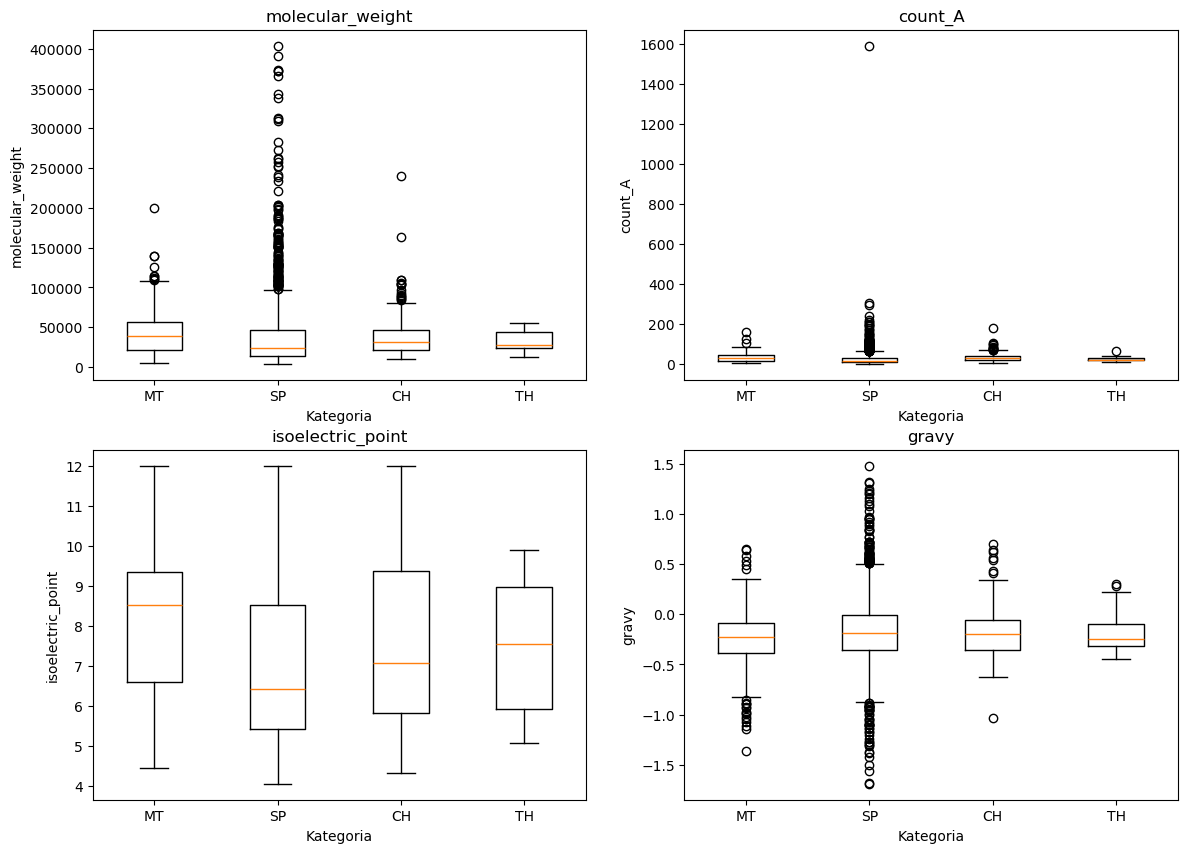

In [73]:
#Wykresy pudełkowe
import matplotlib.pyplot as plt

cechy = ['molecular_weight', 'count_A', 'isoelectric_point', 'gravy']
kategorie = ['MT', 'SP', 'CH', 'TH']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for i, cecha in enumerate(cechy):
    dane_do_wykresu = [df_final[df_final['Target'] == kat][cecha] for kat in kategorie]

    axes[i].boxplot(dane_do_wykresu, tick_labels=kategorie)
    axes[i].set_title(f'{cecha}')
    axes[i].set_xlabel('Kategoria')
    axes[i].set_ylabel(cecha)

plt.show()

In [80]:
#Różne modele
from imblearn.over_sampling import SMOTE

# MODEL 1
model_baza = LogisticRegression(penalty='l2', C=1.0, max_iter=2000)
model_baza.fit(X_train_std, y_train)
print(f"1. Dokładność modelu bazowego -> {model_baza.score(X_test_std, y_test):.4f}")


# MODEL 2 - Daje większą karę za błędy na klasach mniejszościowych

model_balans = LogisticRegression(class_weight='balanced', max_iter=2000)
model_balans.fit(X_train_std, y_train)
print(f"2. Dokładność modelu z class_weight  -> {model_balans.score(X_test_std, y_test):.4f}")

# MODEL 3 - SMOTE (Dogenerowanie sztucznych danych dla zbioru testowego)

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_std, y_train)

model_smote = LogisticRegression(max_iter=2000)
model_smote.fit(X_train_smote, y_train_smote)
print(f"3. Dokładność modelu z danymi SMOTE  -> {model_smote.score(X_test_std, y_test):.4f}")

# MODEL 4: Nieliniowe transformacje (PolynomialFeatures)

poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_std)
X_test_poly = poly.transform(X_test_std) # Tylko transform!

model_poly = LogisticRegression(max_iter=2000)
model_poly.fit(X_train_poly, y_train)
print(f"4. Dokłdność modelu nieliniowego (Poly)-> {model_poly.score(X_test_poly, y_test):.4f}")

# MODEL 5 - Regularyzacja Lasso (Zabija wagi najmniej istotnych cech)

model_lasso = LogisticRegression(penalty='l1', solver='liblinear', C=0.01, max_iter=2000)
model_lasso.fit(X_train_std, y_train)
print(f"5. Dokładność modelu Lasso -> {model_lasso.score(X_test_std, y_test):.4f}")

1. Dokładność modelu bazowego -> 0.7752
2. Dokładność modelu z class_weight  -> 0.5447
3. Dokładność modelu z danymi SMOTE  -> 0.5399
4. Dokłdność modelu nieliniowego (Poly)-> 0.7896
5. Dokładność modelu Lasso -> 0.7781


/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(


<h4> Największy wynik dokładności uzyskał model nieliniowy (Poly), którego wynik jest wyższy niż oryginalnego modelu (0.077); najgorzej poradził sobie model z danymi SMOTE. Szczerze nie do końca rozumiem czemu sa takie wyniki :(.  Co do SMOTE, gdyby był stosowany na danych przed podziałem na zbiory testowe i treningowe, to program mógłby ,,nauczyć się ich" i zbiór testowy przestawałby mieć sens. 